# 03 - Evaluación de modelos

Este notebook evalúa los modelos supervisados base entrenados en `02_supervised_modeling.ipynb`.

El objetivo es comparar su desempeño sobre el conjunto de prueba, revisar estabilidad mediante validación cruzada sobre entrenamiento, interpretar errores y dejar definidos los candidatos para la etapa de optimización.

El notebook no entrena modelos desde cero como producto principal, no crea una nueva versión del dataset y no realiza optimización de hiperparámetros. Los modelos evaluados son los pipelines entrenados y serializados por el notebook 02.

## 1. Preparación del entorno

Se cargan librerías, rutas del proyecto y funciones auxiliares de evaluación. Las rutas se construyen de forma relativa para mantener reproducibilidad entre entornos.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model_evaluation import (
    evaluar_modelos_clasificacion,
    evaluar_modelos_regresion,
    validacion_cruzada_clasificacion,
    validacion_cruzada_regresion,
    guardar_metricas,
    obtener_score_clasificacion,
)

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PLOTS_DIR = PROJECT_ROOT / "results" / "plots"
SPLITS_DIR = PROJECT_ROOT / "results" / "splits"
MODELS_DIR = PROJECT_ROOT / "models" / "trained_models"

for directory in [METRICS_DIR, PLOTS_DIR, SPLITS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

METADATA_PATH = MODELS_DIR / "modeling_metadata.json"
MANIFEST_PATH = MODELS_DIR / "trained_models_manifest.csv"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró models/trained_models/modeling_metadata.json. "
        "Ejecuta primero notebooks/02_supervised_modeling.ipynb."
    )

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "No se encontró models/trained_models/trained_models_manifest.csv. "
        "Ejecuta primero notebooks/02_supervised_modeling.ipynb."
    )

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

DATA_PATH = PROJECT_ROOT / metadata["data_path"]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset indicado en metadata: {DATA_PATH}")

print("Proyecto raíz:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Manifest de modelos:", MANIFEST_PATH)

Proyecto raíz: /datasets/_deepnote_work
Dataset: /datasets/_deepnote_work/data/processed/data_transformada.csv
Metadata: /datasets/_deepnote_work/models/trained_models/modeling_metadata.json
Manifest de modelos: /datasets/_deepnote_work/models/trained_models/trained_models_manifest.csv


## 2. Carga de dataset y modelos entrenados

Se carga el dataset utilizado como base de modelado y el manifiesto de modelos generado en el notebook 02. A partir del manifiesto se cargan los pipelines entrenados para clasificación y regresión.

In [2]:
df = pd.read_csv(DATA_PATH)
df_manifest = pd.read_csv(MANIFEST_PATH)

print("Dimensiones del dataset:", df.shape)
print("Modelos registrados:")
display(df_manifest)

modelos_clasificacion_entrenados = {}
modelos_regresion_entrenados = {}

for _, fila in df_manifest.iterrows():
    ruta_modelo = PROJECT_ROOT / fila["ruta_modelo"]
    if not ruta_modelo.exists():
        raise FileNotFoundError(f"No se encontró el modelo serializado: {ruta_modelo}")

    modelo = joblib.load(ruta_modelo)

    if fila["tipo_modelo"] == "classification":
        modelos_clasificacion_entrenados[fila["modelo"]] = modelo
    elif fila["tipo_modelo"] == "regression":
        modelos_regresion_entrenados[fila["modelo"]] = modelo

print("Modelos de clasificación cargados:", list(modelos_clasificacion_entrenados.keys()))
print("Modelos de regresión cargados:", list(modelos_regresion_entrenados.keys()))

Dimensiones del dataset: (20000, 38)
Modelos registrados:


,tipo_modelo,modelo,ruta_modelo,target
0,classification,Logistic Regression,models/trained_models/classification_logistic_...,abandono
1,classification,Decision Tree Classifier,models/trained_models/classification_decision_...,abandono
2,classification,SVM,models/trained_models/classification_svm_pipel...,abandono
3,regression,Linear Regression,models/trained_models/regression_linear_regres...,gasto_mensual
4,regression,Decision Tree Regressor,models/trained_models/regression_decision_tree...,gasto_mensual


Modelos de clasificación cargados: ['Logistic Regression', 'Decision Tree Classifier', 'SVM']
Modelos de regresión cargados: ['Linear Regression', 'Decision Tree Regressor']


## 3. Reconstrucción de conjuntos de evaluación

Los modelos ya fueron entrenados en el notebook 02. En esta etapa se reconstruyen los mismos conjuntos de entrenamiento y prueba usando los índices guardados. Esto permite evaluar exactamente sobre la misma partición definida en el modelado base.

### 3.1 Clasificación: abandono

Se reconstruyen las variables predictoras y el target de clasificación. Se excluye `id_cliente` si existe, porque identifica registros pero no representa una variable predictiva de comportamiento.

In [3]:
TARGET_CLASIFICACION = metadata["target_clasificacion"]
TARGET_REGRESION = metadata["target_regresion"]
RANDOM_STATE = metadata["random_state"]
TEST_SIZE = metadata["test_size"]

classification_test_indices_path = PROJECT_ROOT / metadata["classification_test_indices"]
classification_train_indices_path = PROJECT_ROOT / metadata["classification_train_indices"]
label_mapping_path = PROJECT_ROOT / metadata["classification_label_mapping"]

for path in [classification_test_indices_path, classification_train_indices_path, label_mapping_path]:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró archivo requerido: {path}")

df_clf = df.dropna(subset=[TARGET_CLASIFICACION]).copy()

columnas_excluir_clf = [TARGET_CLASIFICACION]
if "id_cliente" in df_clf.columns:
    columnas_excluir_clf.append("id_cliente")

X_clf = df_clf.drop(columns=columnas_excluir_clf)
y_clf_original = df_clf[TARGET_CLASIFICACION]

label_encoder_clf = LabelEncoder()
y_clf = pd.Series(
    label_encoder_clf.fit_transform(y_clf_original),
    index=df_clf.index,
    name=TARGET_CLASIFICACION,
)

test_indices_clf = pd.read_csv(classification_test_indices_path)["index"].tolist()
train_indices_clf = pd.read_csv(classification_train_indices_path)["index"].tolist()

X_test_clf = X_clf.loc[test_indices_clf]
y_test_clf = y_clf.loc[test_indices_clf]
X_train_clf = X_clf.loc[train_indices_clf]
y_train_clf = y_clf.loc[train_indices_clf]

df_label_mapping = pd.read_csv(label_mapping_path)

print("Columnas excluidas en clasificación:", columnas_excluir_clf)
print("Train clasificación:", X_train_clf.shape)
print("Test clasificación:", X_test_clf.shape)
print("Mapeo del target:")
display(df_label_mapping)

Columnas excluidas en clasificación: ['abandono']
Train clasificación: (16000, 37)
Test clasificación: (4000, 37)
Mapeo del target:


,clase_original,clase_codificada
0,0,0
1,1,1


### 3.2 Regresión: gasto mensual

Se reconstruye el conjunto de regresión. Para evitar fuga de información, se excluye el target `gasto_mensual`, el identificador del cliente, el target de clasificación `abandono` y variables derivadas directamente del gasto si existen.

In [4]:
regression_test_indices_path = PROJECT_ROOT / metadata["regression_test_indices"]
regression_train_indices_path = PROJECT_ROOT / metadata["regression_train_indices"]

for path in [regression_test_indices_path, regression_train_indices_path]:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró archivo requerido: {path}")

df_reg = df.dropna(subset=[TARGET_REGRESION]).copy()

columnas_excluir_reg = [TARGET_REGRESION]
for col in ["id_cliente", TARGET_CLASIFICACION, "ratio_gasto_ingreso"]:
    if col in df_reg.columns:
        columnas_excluir_reg.append(col)

X_reg = df_reg.drop(columns=columnas_excluir_reg)
y_reg = pd.to_numeric(df_reg[TARGET_REGRESION], errors="coerce")

filas_validas_reg = y_reg.notna()
X_reg = X_reg.loc[filas_validas_reg]
y_reg = y_reg.loc[filas_validas_reg]

test_indices_reg = pd.read_csv(regression_test_indices_path)["index"].tolist()
train_indices_reg = pd.read_csv(regression_train_indices_path)["index"].tolist()

X_test_reg = X_reg.loc[test_indices_reg]
y_test_reg = y_reg.loc[test_indices_reg]
X_train_reg = X_reg.loc[train_indices_reg]
y_train_reg = y_reg.loc[train_indices_reg]

print("Columnas excluidas en regresión:", columnas_excluir_reg)
print("Train regresión:", X_train_reg.shape)
print("Test regresión:", X_test_reg.shape)

Columnas excluidas en regresión: ['gasto_mensual', 'abandono', 'ratio_gasto_ingreso']
Train regresión: (16000, 35)
Test regresión: (4000, 35)


# Evaluación de clasificación

La evaluación de clasificación compara los modelos entrenados para predecir `abandono`. Se analizan métricas globales, errores por clase, capacidad de separación y sensibilidad del umbral de decisión.

## 4. Métricas de clasificación sobre test

Las métricas principales permiten observar distintos aspectos del rendimiento:

- `accuracy`: proporción total de aciertos.
- `precision`: confiabilidad cuando el modelo predice abandono.
- `recall`: capacidad para detectar clientes que realmente abandonan.
- `f1_score`: equilibrio entre precision y recall.
- `roc_auc`: capacidad general de separación entre clases.

In [5]:
df_clf_test_metrics, matrices_confusion = evaluar_modelos_clasificacion(
    modelos_clasificacion_entrenados,
    X_test_clf,
    y_test_clf,
)

df_clf_test_metrics = df_clf_test_metrics.sort_values(
    by=["f1_score", "roc_auc", "recall"],
    ascending=False,
).reset_index(drop=True)

classification_test_metrics_path = METRICS_DIR / "classification_test_metrics.csv"
guardar_metricas(df_clf_test_metrics, classification_test_metrics_path)

display(df_clf_test_metrics)
print("Métricas de clasificación guardadas en:", classification_test_metrics_path)

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.65500,0.604230,0.378072,0.465116,0.688220
1,Decision Tree Classifier,0.55875,0.447212,0.475110,0.460739,0.544435
2,SVM,0.64450,0.602230,0.306238,0.406015,0.656956


Métricas de clasificación guardadas en: /datasets/_deepnote_work/results/metrics/classification_test_metrics.csv


### Lectura de métricas de clasificación

`Logistic Regression` presenta el mejor equilibrio general entre `accuracy`, `f1_score` y `roc_auc`, por lo que se posiciona como el modelo base más consistente.

`Decision Tree Classifier` alcanza el mayor `recall`, lo que indica que detecta más clientes que abandonan. Sin embargo, su menor `precision` anticipa un mayor número de falsas alertas.

`SVM` mantiene una `precision` similar a `Logistic Regression`, pero su `recall` es menor. Esto sugiere un comportamiento más conservador: predice menos casos como abandono y deja pasar más clientes que sí abandonan.

## 5. Matrices de confusión

Las matrices de confusión permiten observar el tipo de error cometido por cada modelo. En este problema, los falsos negativos son especialmente relevantes porque representan clientes que realmente abandonan, pero el modelo no detecta.

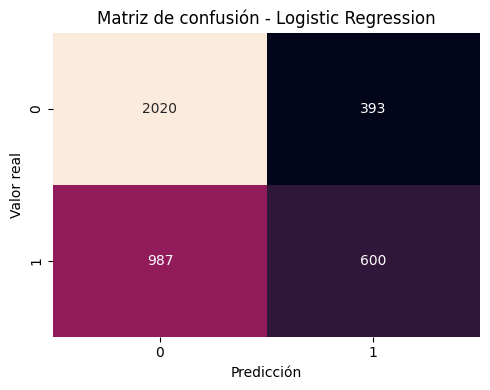

Gráfico guardado en: /datasets/_deepnote_work/results/plots/confusion_matrix_logistic_regression.png


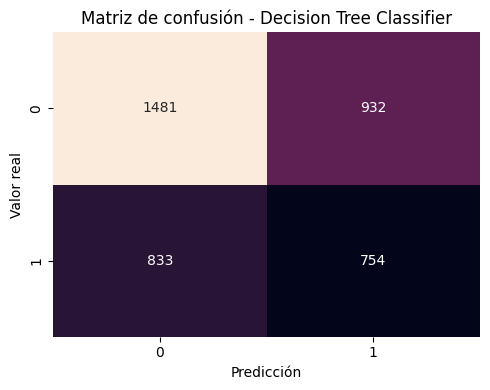

Gráfico guardado en: /datasets/_deepnote_work/results/plots/confusion_matrix_decision_tree_classifier.png


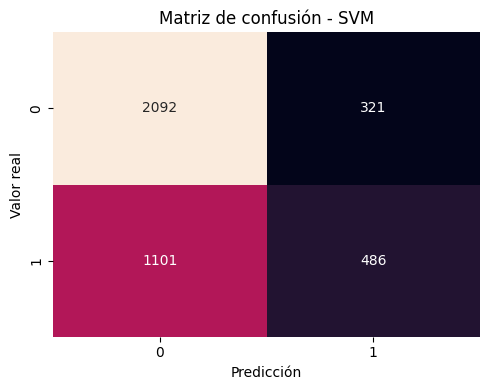

Gráfico guardado en: /datasets/_deepnote_work/results/plots/confusion_matrix_svm.png


In [6]:
class_labels = [str(label) for label in label_encoder_clf.classes_]

for nombre, matriz in matrices_confusion.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
    )
    ax.set_title(f"Matriz de confusión - {nombre}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    plt.tight_layout()

    nombre_archivo = nombre.lower().replace(" ", "_")
    output_path = PLOTS_DIR / f"confusion_matrix_{nombre_archivo}.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico guardado en:", output_path)

### Lectura de matrices de confusión

`Logistic Regression` muestra un comportamiento equilibrado, pero todavía deja una cantidad importante de abandonos reales sin detectar.

`Decision Tree Classifier` identifica más casos reales de abandono que los otros modelos, aunque genera un número elevado de falsos positivos. Esto confirma que su mayor `recall` tiene un costo importante en precisión.

`SVM` produce menos falsos positivos, pero también detecta menos abandonos reales. Su comportamiento es más conservador y puede ser insuficiente si el objetivo principal es anticipar clientes en riesgo.

## 6. Curva ROC comparativa

La curva ROC permite comparar la capacidad de separación de los modelos entre clientes que abandonan y no abandonan. A diferencia de una matriz de confusión, no depende únicamente del umbral de decisión por defecto.

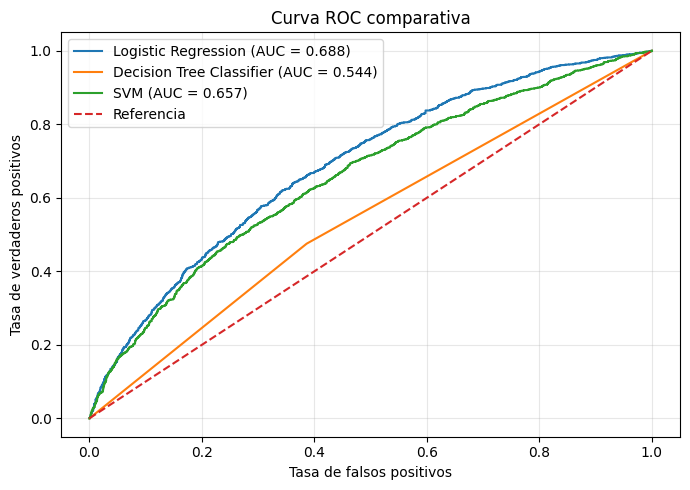

Curva ROC guardada en: /datasets/_deepnote_work/results/plots/roc_curve_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

roc_generada = False

for nombre, modelo in modelos_clasificacion_entrenados.items():
    y_score = obtener_score_clasificacion(modelo, X_test_clf)

    if y_score is None or len(np.unique(y_test_clf)) != 2:
        continue

    fpr, tpr, _ = roc_curve(y_test_clf, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")
    roc_generada = True

if roc_generada:
    ax.plot([0, 1], [0, 1], linestyle="--", label="Referencia")
    ax.set_title("Curva ROC comparativa")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    roc_path = PLOTS_DIR / "roc_curve_comparison.png"
    fig.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Curva ROC guardada en:", roc_path)
else:
    plt.close(fig)
    print("No fue posible generar curva ROC con los modelos disponibles.")

### Lectura de curva ROC

`Logistic Regression` presenta la mayor capacidad de separación global entre clases, lo que confirma su mejor rendimiento general en clasificación.

`SVM` obtiene una separación intermedia. Aunque su matriz de confusión muestra bajo `recall` con el umbral base, su curva ROC indica que el modelo conserva cierta capacidad para ordenar casos según riesgo.

`Decision Tree Classifier` presenta el AUC más bajo. Esto muestra que su mayor `recall` no implica una mejor separación general, sino una regla de clasificación más propensa a marcar clientes como abandono.

## 7. Comparación visual de métricas de clasificación

El gráfico permite observar de forma conjunta qué modelo domina cada métrica y dónde aparecen los principales trade-offs.

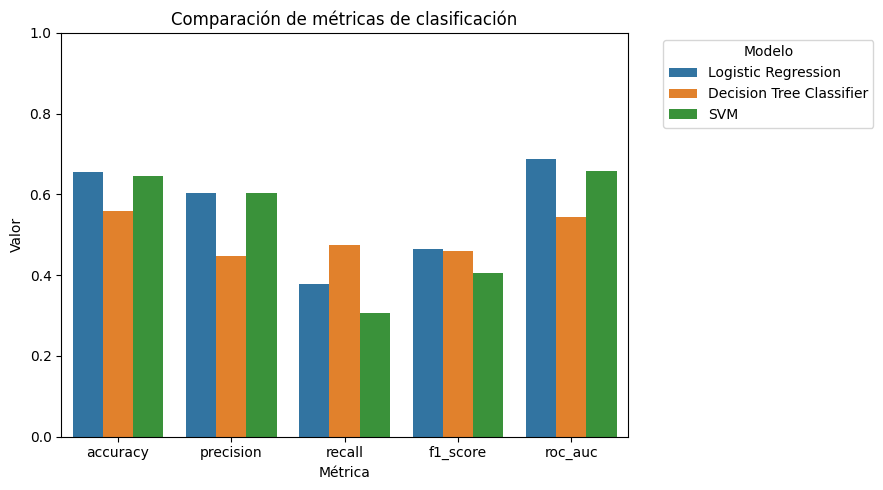

Gráfico comparativo guardado en: /datasets/_deepnote_work/results/plots/classification_metrics_comparison.png


In [8]:
metricas_clf_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

df_clf_plot = df_clf_test_metrics.melt(
    id_vars="modelo",
    value_vars=metricas_clf_plot,
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_clf_plot, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_title("Comparación de métricas de clasificación")
ax.set_ylim(0, 1)
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

classification_plot_path = PLOTS_DIR / "classification_metrics_comparison.png"
fig.savefig(classification_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico comparativo guardado en:", classification_plot_path)

### Lectura de comparación visual

Ningún modelo domina todas las métricas. `Logistic Regression` mantiene el mejor equilibrio general, especialmente en `accuracy`, `f1_score` y `roc_auc`.

`Decision Tree Classifier` destaca en `recall`, pero su baja `precision` confirma que detecta más abandonos a costa de muchas falsas alertas.

`SVM` presenta una precisión competitiva, pero su baja detección de casos positivos reduce su utilidad si la prioridad es anticipar abandono.

## 8. Validación cruzada de clasificación sobre entrenamiento

La validación cruzada se aplica sobre el conjunto de entrenamiento para estimar estabilidad del rendimiento sin utilizar el conjunto de prueba. El test se mantiene como evaluación independiente de los modelos entrenados en el notebook 02.

In [9]:
df_clf_cv_metrics = validacion_cruzada_clasificacion(
    modelos_clasificacion_entrenados,
    X_train_clf,
    y_train_clf,
    cv_splits=5,
    random_state=RANDOM_STATE,
)

classification_cv_metrics_path = METRICS_DIR / "classification_cv_metrics.csv"
guardar_metricas(df_clf_cv_metrics, classification_cv_metrics_path)

display(df_clf_cv_metrics)
print("Validación cruzada de clasificación guardada en:", classification_cv_metrics_path)

,modelo,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.6480,0.004125,0.590950,0.009617,0.366886,0.005928,0.452662,0.005687,0.671692,0.005276
1,Decision Tree Classifier,0.5575,0.006582,0.443482,0.008056,0.452110,0.007689,0.447741,0.007483,0.539462,0.006537
2,SVM,0.6435,0.004966,0.597874,0.013495,0.310492,0.003954,0.408682,0.005527,0.644577,0.006762


Validación cruzada de clasificación guardada en: /datasets/_deepnote_work/results/metrics/classification_cv_metrics.csv


### Lectura de validación cruzada de clasificación

Los resultados de validación cruzada son coherentes con la evaluación en test: `Logistic Regression` mantiene el mejor equilibrio general, `Decision Tree Classifier` conserva mayor orientación hacia el `recall`, y `SVM` mantiene un comportamiento más conservador.

La baja desviación estándar en las métricas indica que las diferencias no dependen únicamente de una partición aislada de los datos.

## 9. Análisis de sensibilidad del umbral de decisión

Este análisis no modifica el modelo ni constituye una optimización de hiperparámetros. Su objetivo es mostrar cómo cambia el equilibrio entre `precision`, `recall` y `f1_score` cuando se modifica el criterio de decisión usado para clasificar a un cliente como abandono.

La elección final de un umbral depende del criterio de negocio. Si se prioriza detectar la mayor cantidad posible de clientes en riesgo, puede preferirse un umbral menor. Si se busca reducir falsas alertas, puede preferirse un umbral mayor.

El análisis se aplica a `Logistic Regression`, ya que entrega probabilidades directamente mediante `predict_proba`.

In [10]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
modelo_threshold_nombre = "Logistic Regression"
threshold_analysis_path = METRICS_DIR / "threshold_analysis_classification.csv"
threshold_plot_path = None

if modelo_threshold_nombre not in modelos_clasificacion_entrenados:
    raise KeyError(f"No se encontró el modelo requerido para análisis de umbral: {modelo_threshold_nombre}")

modelo_threshold = modelos_clasificacion_entrenados[modelo_threshold_nombre]

if not hasattr(modelo_threshold, "predict_proba"):
    df_threshold_analysis = pd.DataFrame()
    print(f"{modelo_threshold_nombre}: no dispone de predict_proba; se omite análisis de umbral.")
else:
    y_proba = modelo_threshold.predict_proba(X_test_clf)[:, 1]
    resultados_threshold = []

    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)

        resultados_threshold.append({
            "modelo": modelo_threshold_nombre,
            "threshold": threshold,
            "accuracy": accuracy_score(y_test_clf, y_pred_threshold),
            "precision": precision_score(y_test_clf, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test_clf, y_pred_threshold, zero_division=0),
            "f1_score": f1_score(y_test_clf, y_pred_threshold, zero_division=0),
        })

    df_threshold_analysis = pd.DataFrame(resultados_threshold)
    guardar_metricas(df_threshold_analysis, threshold_analysis_path)

    display(df_threshold_analysis)
    print("Análisis de umbral guardado en:", threshold_analysis_path)

,modelo,threshold,accuracy,precision,recall,f1_score
0,Logistic Regression,0.3,0.56950,0.475884,0.839319,0.607387
1,Logistic Regression,0.4,0.63800,0.537346,0.630120,0.580046
2,Logistic Regression,0.5,0.65500,0.604230,0.378072,0.465116
3,Logistic Regression,0.6,0.64225,0.674107,0.190296,0.296806
4,Logistic Regression,0.7,0.61750,0.728000,0.057341,0.106308


Análisis de umbral guardado en: /datasets/_deepnote_work/results/metrics/threshold_analysis_classification.csv


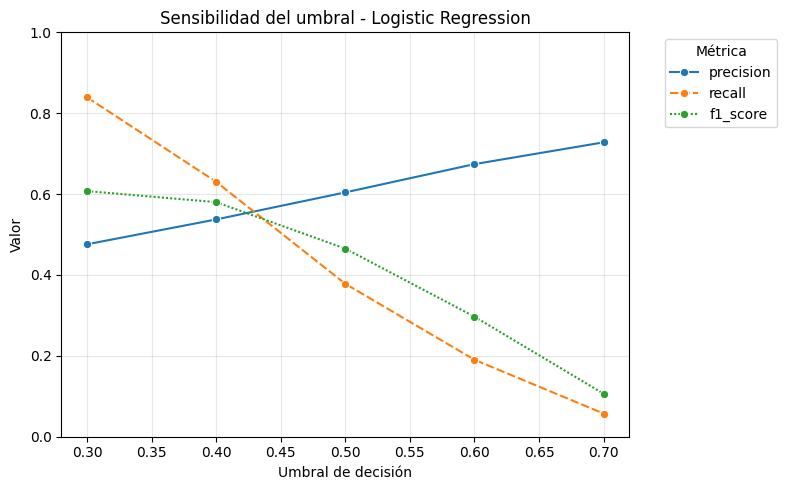

Gráfico de umbral guardado en: /datasets/_deepnote_work/results/plots/threshold_analysis_classification.png


In [11]:
if not df_threshold_analysis.empty:
    df_threshold_plot = df_threshold_analysis.melt(
        id_vars=["modelo", "threshold"],
        value_vars=["precision", "recall", "f1_score"],
        var_name="metrica",
        value_name="valor",
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(
        data=df_threshold_plot,
        x="threshold",
        y="valor",
        hue="metrica",
        style="metrica",
        marker="o",
        ax=ax,
    )

    ax.set_title("Sensibilidad del umbral - Logistic Regression")
    ax.set_xlabel("Umbral de decisión")
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    threshold_plot_path = PLOTS_DIR / "threshold_analysis_classification.png"
    fig.savefig(threshold_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico de umbral guardado en:", threshold_plot_path)
else:
    print("No se generó gráfico de umbral.")

### Lectura del análisis de umbral

Con el umbral por defecto de 0.5, `Logistic Regression` presenta una precisión mayor, pero un `recall` limitado. Esto significa que el modelo es relativamente cuidadoso al predecir abandono, pero deja sin detectar una proporción importante de clientes que realmente abandonan.

Al reducir el umbral, el modelo clasifica más clientes como abandono. Esto aumenta el `recall`, pero reduce la `precision`, porque también aumentan las falsas alertas.

El umbral 0.3 maximiza fuertemente la detección de abandonos, mientras que 0.4 ofrece un equilibrio intermedio entre `precision`, `recall` y `f1_score`. La elección de un umbral no debe tratarse como una optimización técnica aislada, sino como una decisión de negocio sobre qué tipo de error es más costoso.

# Evaluación de regresión

La regresión se evalúa como componente complementario del análisis. Su objetivo es estimar `gasto_mensual`, una variable numérica vinculada al valor económico del cliente.

## 10. Métricas de regresión sobre test

Se comparan `Linear Regression` y `Decision Tree Regressor` usando:

- `MAE`: error absoluto promedio.
- `RMSE`: error que penaliza con más fuerza errores grandes.
- `R²`: capacidad explicativa del modelo respecto a la variabilidad del target.

In [12]:
df_reg_test_metrics = evaluar_modelos_regresion(
    modelos_regresion_entrenados,
    X_test_reg,
    y_test_reg,
)

df_reg_test_metrics = df_reg_test_metrics.sort_values(
    by=["rmse", "mae", "r2"],
    ascending=[True, True, False],
).reset_index(drop=True)

regression_test_metrics_path = METRICS_DIR / "regression_test_metrics.csv"
guardar_metricas(df_reg_test_metrics, regression_test_metrics_path)

display(df_reg_test_metrics)
print("Métricas de regresión guardadas en:", regression_test_metrics_path)

,modelo,mae,rmse,r2
0,Linear Regression,0.816198,1.006341,-0.001883
1,Decision Tree Regressor,1.152062,1.426339,-1.012671


Métricas de regresión guardadas en: /datasets/_deepnote_work/results/metrics/regression_test_metrics.csv


### Lectura de métricas de regresión

`Linear Regression` obtiene menor `MAE` y menor `RMSE` que `Decision Tree Regressor`, por lo que es el mejor modelo base de regresión entre los evaluados.

Sin embargo, su `R²` es cercano a cero y levemente negativo, lo que indica una capacidad explicativa muy limitada sobre `gasto_mensual`. El modelo no está capturando relaciones suficientemente fuertes para explicar la variabilidad del target.

`Decision Tree Regressor` presenta un rendimiento base deficiente, con errores mayores y un `R²` considerablemente negativo.

## 11. Comparación visual de errores de regresión

Se grafican por separado `MAE` y `RMSE`, ya que ambas métricas representan error y se interpretan en la misma dirección: valores menores indican mejor rendimiento.

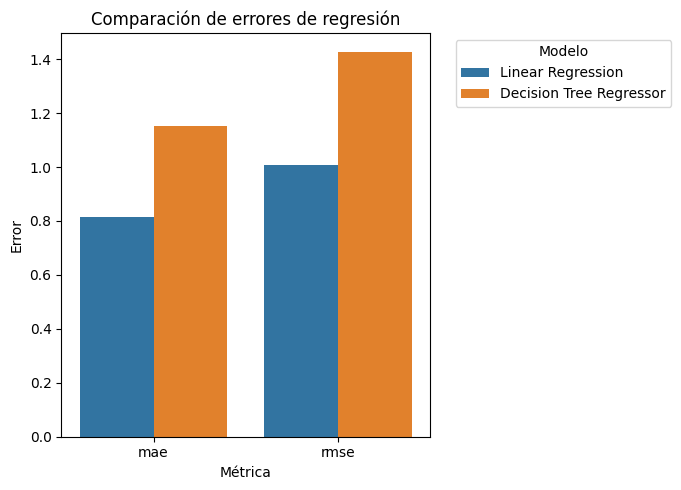

Gráfico de errores guardado en: /datasets/_deepnote_work/results/plots/regression_error_metrics_comparison.png


In [13]:
df_reg_error_plot = df_reg_test_metrics.melt(
    id_vars="modelo",
    value_vars=["mae", "rmse"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df_reg_error_plot, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_title("Comparación de errores de regresión")
ax.set_xlabel("Métrica")
ax.set_ylabel("Error")
ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

regression_error_plot_path = PLOTS_DIR / "regression_error_metrics_comparison.png"
fig.savefig(regression_error_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico de errores guardado en:", regression_error_plot_path)

### Lectura de errores de regresión

El gráfico confirma que `Linear Regression` presenta menor error que `Decision Tree Regressor` tanto en `MAE` como en `RMSE`. Esto refuerza su rol como mejor línea base de regresión.

Aun así, un menor error relativo entre modelos no implica necesariamente buena capacidad predictiva. Para eso se revisa también el `R²`.

## 12. Comparación de R² en regresión

El `R²` se muestra en un gráfico separado porque se interpreta de forma distinta a `MAE` y `RMSE`. En este caso, la línea vertical en cero funciona como referencia: valores bajo cero indican que el modelo rinde peor que una predicción simple basada en el promedio.

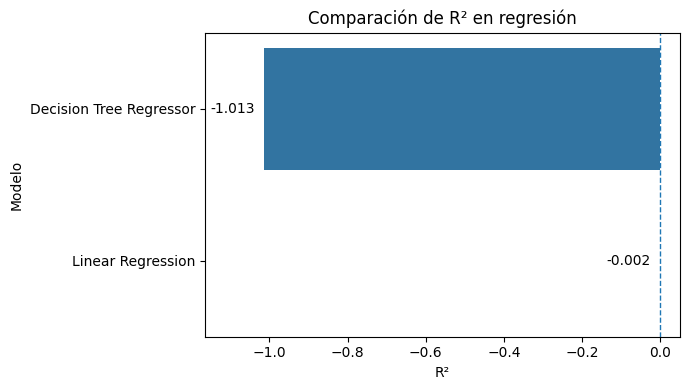

Gráfico de R² guardado en: /datasets/_deepnote_work/results/plots/regression_r2_comparison.png


In [14]:
df_r2_plot = df_reg_test_metrics[["modelo", "r2"]].sort_values("r2", ascending=True).copy()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df_r2_plot, y="modelo", x="r2", ax=ax)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Comparación de R² en regresión")
ax.set_xlabel("R²")
ax.set_ylabel("Modelo")

xmin = min(df_r2_plot["r2"].min() * 1.15, -0.05)
xmax = max(df_r2_plot["r2"].max() * 1.15, 0.05)
ax.set_xlim(xmin, xmax)

offset = (xmax - xmin) * 0.02
for pos, (_, row) in enumerate(df_r2_plot.iterrows()):
    value = row["r2"]
    if value < 0:
        ax.text(value - offset, pos, f"{value:.3f}", va="center", ha="right")
    else:
        ax.text(value + offset, pos, f"{value:.3f}", va="center", ha="left")

plt.tight_layout()

regression_r2_plot_path = PLOTS_DIR / "regression_r2_comparison.png"
fig.savefig(regression_r2_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico de R² guardado en:", regression_r2_plot_path)

### Lectura de R²

Ambos modelos presentan `R²` negativo, por lo que no explican adecuadamente la variabilidad de `gasto_mensual`.

`Linear Regression` se mantiene cerca de cero, lo que indica un rendimiento débil pero menos problemático que el árbol. `Decision Tree Regressor` se aleja considerablemente de cero en sentido negativo, por lo que su configuración base resulta deficiente.

La regresión debe interpretarse como componente complementario del proyecto, no como el eje principal del análisis predictivo.

## 13. Predicción vs valor real

Los gráficos de dispersión comparan los valores reales con las predicciones de cada modelo de regresión. Una predicción ideal seguiría la línea diagonal.

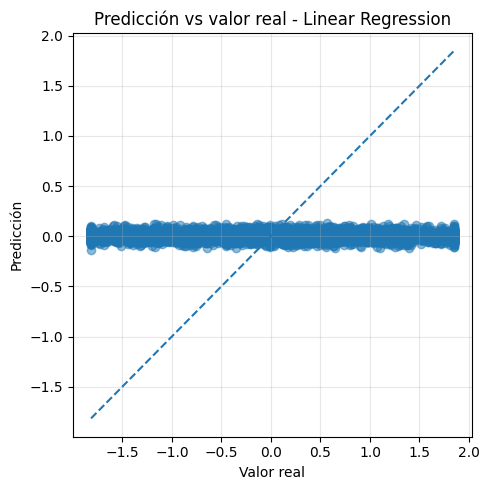

Gráfico guardado en: /datasets/_deepnote_work/results/plots/regression_predictions_linear_regression.png


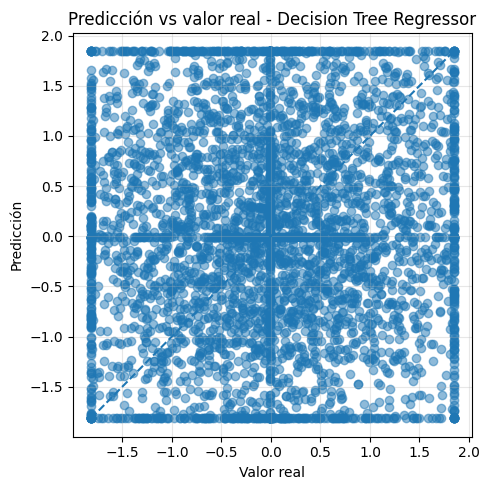

Gráfico guardado en: /datasets/_deepnote_work/results/plots/regression_predictions_decision_tree_regressor.png


In [15]:
for nombre, modelo in modelos_regresion_entrenados.items():
    y_pred = modelo.predict(X_test_reg)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_test_reg, y_pred, alpha=0.5)

    min_val = min(np.min(y_test_reg), np.min(y_pred))
    max_val = max(np.max(y_test_reg), np.max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_title(f"Predicción vs valor real - {nombre}")
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Predicción")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    nombre_archivo = nombre.lower().replace(" ", "_")
    output_path = PLOTS_DIR / f"regression_predictions_{nombre_archivo}.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico guardado en:", output_path)

### Lectura de predicción vs valor real

Los gráficos permiten observar visualmente la dispersión de las predicciones. La baja capacidad explicativa observada en `R²` indica que las predicciones no siguen de forma consistente la diagonal ideal.

Esto confirma que los modelos base de regresión no capturan adecuadamente el comportamiento de `gasto_mensual` con las variables disponibles en esta etapa.

## 14. Validación cruzada de regresión sobre entrenamiento

La validación cruzada se aplica sobre entrenamiento para estimar estabilidad de los modelos de regresión sin utilizar el conjunto de prueba.

In [16]:
df_reg_cv_metrics = validacion_cruzada_regresion(
    modelos_regresion_entrenados,
    X_train_reg,
    y_train_reg,
    cv_splits=5,
    random_state=RANDOM_STATE,
)

regression_cv_metrics_path = METRICS_DIR / "regression_cv_metrics.csv"
guardar_metricas(df_reg_cv_metrics, regression_cv_metrics_path)

display(df_reg_cv_metrics)
print("Validación cruzada de regresión guardada en:", regression_cv_metrics_path)

,modelo,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,Linear Regression,0.810782,0.007134,0.999974,0.008001,-0.003173,0.002201
1,Decision Tree Regressor,1.180067,0.014882,1.449443,0.013453,-1.108214,0.050654


Validación cruzada de regresión guardada en: /datasets/_deepnote_work/results/metrics/regression_cv_metrics.csv


### Lectura de validación cruzada de regresión

La validación cruzada confirma el patrón observado en test: `Linear Regression` mantiene menor error promedio y mejor `R²` que `Decision Tree Regressor`.

El rendimiento negativo de `R²` en ambos casos muestra que el problema de regresión es débil con los modelos base utilizados. Esto no invalida el análisis, pero limita su interpretación como herramienta predictiva principal.

# Síntesis y candidatos para optimización

Esta sección resume los hallazgos y define qué modelos pasan a la etapa de optimización de hiperparámetros. La selección se basa en el rendimiento observado, el tipo de error cometido y la posibilidad real de ajustar hiperparámetros.

In [17]:
# Clasificación:
# Se incluyen candidatos según el diagnóstico del 03:
# - Logistic Regression: mejor equilibrio general.
# - Decision Tree Classifier: mayor recall, pero con demasiados falsos positivos.
# - SVM: candidato opcional por costo computacional y bajo recall base.

orden_clasificacion = [
    "Logistic Regression",
    "Decision Tree Classifier",
    "SVM",
]

rol_clasificacion = {
    "Logistic Regression": "candidato_principal",
    "Decision Tree Classifier": "candidato_principal",
    "SVM": "candidato_opcional",
}

justificacion_clasificacion = {
    "Logistic Regression": "Mejor equilibrio general en la comparación base entre accuracy, f1_score y roc_auc.",
    "Decision Tree Classifier": "Mayor recall, pero con alto número de falsos positivos; requiere control de complejidad.",
    "SVM": "ROC-AUC aceptable y comportamiento conservador; optimización sujeta a costo computacional.",
}

candidatos_clasificacion = (
    df_clf_test_metrics[df_clf_test_metrics["modelo"].isin(orden_clasificacion)]
    .copy()
)

candidatos_clasificacion["prioridad"] = candidatos_clasificacion["modelo"].map(
    {modelo: i + 1 for i, modelo in enumerate(orden_clasificacion)}
)
candidatos_clasificacion["rol"] = candidatos_clasificacion["modelo"].map(rol_clasificacion)
candidatos_clasificacion["justificacion"] = candidatos_clasificacion["modelo"].map(
    justificacion_clasificacion
)
candidatos_clasificacion = candidatos_clasificacion.sort_values("prioridad").reset_index(drop=True)

# Regresión:
# Linear Regression se mantiene como baseline.
# Decision Tree Regressor se considera candidato optimizable por tener hiperparámetros claros.

justificacion_regresion = {
    "Linear Regression": "Se mantiene como baseline; no requiere optimización fuerte en esta configuración.",
    "Decision Tree Regressor": "Candidato optimizable; requiere control de complejidad por su bajo rendimiento base.",
}

candidatos_regresion = df_reg_test_metrics.copy()
candidatos_regresion["rol"] = candidatos_regresion["modelo"].map({
    "Linear Regression": "baseline",
    "Decision Tree Regressor": "candidato_optimizable",
})
candidatos_regresion["justificacion"] = candidatos_regresion["modelo"].map(
    justificacion_regresion
)

classification_candidates_path = METRICS_DIR / "classification_candidates_for_optimization.csv"
regression_candidates_path = METRICS_DIR / "regression_candidates_for_optimization.csv"

guardar_metricas(candidatos_clasificacion, classification_candidates_path)
guardar_metricas(candidatos_regresion, regression_candidates_path)

print("Candidatos de clasificación para optimización:")
display(candidatos_clasificacion)

print("Candidatos de regresión / baseline para optimización:")
display(candidatos_regresion)

Candidatos de clasificación para optimización:


,modelo,accuracy,precision,recall,f1_score,roc_auc,prioridad,rol,justificacion
0,Logistic Regression,0.65500,0.604230,0.378072,0.465116,0.688220,1,candidato_principal,Mejor equilibrio general en la comparación bas...
1,Decision Tree Classifier,0.55875,0.447212,0.475110,0.460739,0.544435,2,candidato_principal,"Mayor recall, pero con alto número de falsos p..."
2,SVM,0.64450,0.602230,0.306238,0.406015,0.656956,3,candidato_opcional,ROC-AUC aceptable y comportamiento conservador...


Candidatos de regresión / baseline para optimización:


,modelo,mae,rmse,r2,rol,justificacion
0,Linear Regression,0.816198,1.006341,-0.001883,baseline,Se mantiene como baseline; no requiere optimiz...
1,Decision Tree Regressor,1.152062,1.426339,-1.012671,candidato_optimizable,Candidato optimizable; requiere control de com...


## Lectura de candidatos para optimización

`Logistic Regression` pasa como candidato principal porque, en la comparación base, presenta el mejor equilibrio general entre `accuracy`, `f1_score` y `roc_auc`. Esta decisión se basa en las métricas base del modelo y no en el análisis posterior de umbral.

`Decision Tree Classifier` también pasa como candidato principal porque obtiene el mayor `recall`, lo que significa que detecta más clientes que realmente abandonan. Sin embargo, también genera una cantidad elevada de falsos positivos, por lo que requiere controlar su complejidad mediante hiperparámetros como profundidad máxima, mínimo de muestras por división, mínimo de muestras por hoja, criterio y peso de clases.

`SVM` queda como candidato opcional. Su `roc_auc` es aceptable y mantiene un comportamiento conservador, pero su bajo `recall` y su mayor costo computacional hacen que no sea la primera prioridad para optimización.

En regresión, `Linear Regression` se mantiene como línea base. `Decision Tree Regressor` queda como candidato optimizable porque, aunque su rendimiento base es bajo, tiene hiperparámetros claros para controlar complejidad y evaluar si puede mejorar su desempeño.

# Comprobaciones finales

Se verifica que las métricas y gráficos principales hayan sido guardados correctamente.

In [18]:
archivos_requeridos = [
    classification_test_metrics_path,
    regression_test_metrics_path,
    classification_cv_metrics_path,
    regression_cv_metrics_path,
    classification_candidates_path,
    regression_candidates_path,
    classification_plot_path,
    regression_error_plot_path,
    regression_r2_plot_path,
]

if threshold_plot_path is not None:
    archivos_requeridos.append(threshold_analysis_path)
    archivos_requeridos.append(threshold_plot_path)

if 'roc_path' in globals():
    archivos_requeridos.append(roc_path)

checks = []

for path in archivos_requeridos:
    checks.append({
        "archivo": str(path.relative_to(PROJECT_ROOT)),
        "existe": path.exists(),
    })

df_checks = pd.DataFrame(checks)
display(df_checks)

pendientes = (~df_checks["existe"]).sum()
print(f"Archivos pendientes: {pendientes}")

,archivo,existe
0,results/metrics/classification_test_metrics.csv,True
1,results/metrics/regression_test_metrics.csv,True
2,results/metrics/classification_cv_metrics.csv,True
3,results/metrics/regression_cv_metrics.csv,True
4,results/metrics/classification_candidates_for_...,True
5,results/metrics/regression_candidates_for_opti...,True
6,results/plots/classification_metrics_compariso...,True
7,results/plots/regression_error_metrics_compari...,True
8,results/plots/regression_r2_comparison.png,True
9,results/metrics/threshold_analysis_classificat...,True


Archivos pendientes: 0


# Cierre del notebook

La evaluación comparativa muestra que, en la comparación base, `Logistic Regression` presenta el mejor equilibrio general para clasificación, principalmente por sus valores de `accuracy`, `f1_score` y `roc_auc`. Esta conclusión no proviene del análisis de umbral, sino de la comparación inicial entre los modelos base evaluados bajo las mismas condiciones.

Sin embargo, su `recall` con el umbral por defecto es limitado, lo que significa que deja sin detectar una proporción relevante de clientes que realmente abandonan.

`Decision Tree Classifier` detecta más abandonos reales, pero genera demasiados falsos positivos y tiene menor capacidad global de separación. `SVM` muestra un comportamiento más conservador: mantiene una precisión competitiva, pero detecta menos abandonos reales.

El análisis de sensibilidad del umbral evidencia que la clasificación de abandono depende del criterio de decisión utilizado. Esta elección no corresponde a una optimización técnica del modelo, sino a una decisión de negocio sobre el equilibrio entre detectar más clientes en riesgo y evitar falsas alertas.

En regresión, `Linear Regression` supera a `Decision Tree Regressor`, aunque ambos modelos presentan baja capacidad explicativa sobre `gasto_mensual`. Por ello, la regresión se mantiene como componente complementario del análisis.

Los resultados justifican pasar a optimización en el notebook `04_hyperparameter_optimization`, priorizando `Logistic Regression` y `Decision Tree Classifier` para clasificación, manteniendo `SVM` como candidato opcional, y considerando `Decision Tree Regressor` como modelo de regresión optimizable.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a797108b-ff37-4667-9d30-00c3227a6ce3' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>